In [3]:
# IMPORT
from IPython.display import Image, Math

import os
import numpy as np
import pandas as pd
from utils_RAL import *
import pyAgrum
import pyAgrum.skbn as skbn
import pyAgrum.lib.notebook as gnb
import pyAgrum.lib.image as gimg
import pyAgrum.lib.dynamicBN as gdyn
import pyAgrum.causal as pyc
import pyAgrum.causal.notebook as cslnb
# from pyAgrum.lib.discretizer import Discretizer
import re
from sklearn.cluster import KMeans
# from kneed import KneeLocator
from scipy.stats import iqr, gaussian_kde, entropy
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'  # Set background to white globally
plt.rcParams['axes.facecolor'] = 'white'    # Set axis background to white
import warnings
import pickle
warnings.filterwarnings("ignore")

print(pyAgrum.__version__)

1.13.2


In [26]:

def loaf_D(indir, bagname):
    print(f"Loading : {bagname}")
    filename = os.path.join(indir, f"{bagname}", f"{bagname}.csv")
    df = pd.read_csv(filename)
    # df = df[df['B'] < -5]
    df = df[df['L'] > -5]
    df = df[df['L'] < 5]
    df = df.iloc[1:].reset_index(drop=True)  # Remove first row
    
    df = df.drop('B', axis=1)
    df = df.drop('ros_time', axis=1)
    
 
    original_names = list(df.columns)
    df.columns = [f'{v}t' for v in original_names]

    # Add lagged variable
    for v in original_names:
        df[f'{v}0'] = np.concatenate([df[f'{v}t'].values[1:], [0]])
    df = df.iloc[1:].reset_index(drop=True)  # Remove first row
    df = df.iloc[:-1].reset_index(drop=True)  # Remove last row
    return df

In [33]:
INDIR = '/home/lcastri/git/causal-sim2real/HRISim_docker/src/HRISim/postprocessing/hrisim_postprocess/csv_pp-1-battery'
pobs = [10, 30, 50, 20, 40]
filenames = ['test-obs-01', 'test-obs-02', 'test-obs-03', 'test-obs-04', 'test-obs-05']
OUTDIR = "CIE_battery"
for p in pobs:
    dirname = f"{OUTDIR}/CIE_battery_{p}"
    os.makedirs(dirname, exist_ok=True)

datasets = []
for i, filename in enumerate(filenames):
    df = loaf_D(INDIR, filename)
    datasets.append(df)

    dirname = f"{OUTDIR}/CIE_battery_{pobs[i]}"
    with open(f"{dirname}/Ds.pkl", "wb") as f:
        pickle.dump(df, f)

Loading : test-obs-01
Loading : test-obs-02
Loading : test-obs-03
Loading : test-obs-04
Loading : test-obs-05


BN p-obs10 learned.


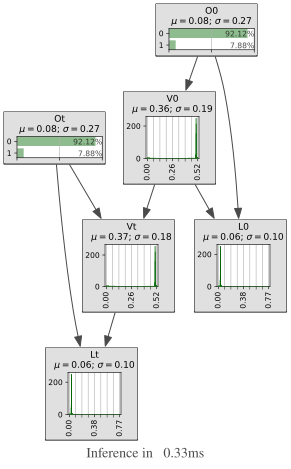

BN p-obs30 learned.


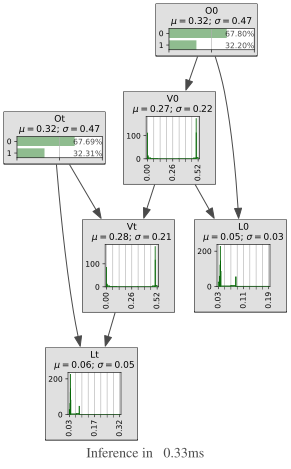

BN p-obs50 learned.


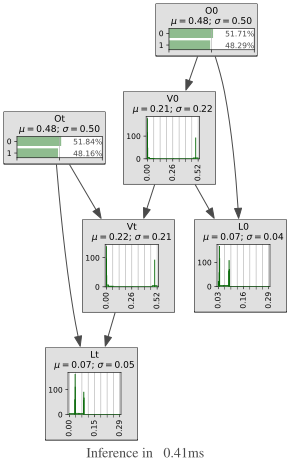

BN p-obs20 learned.


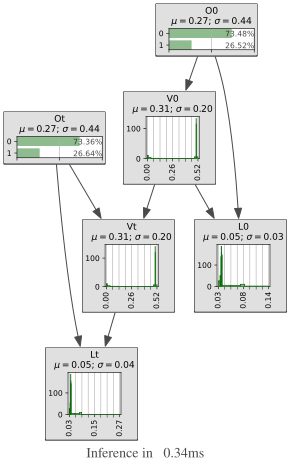

BN p-obs40 learned.


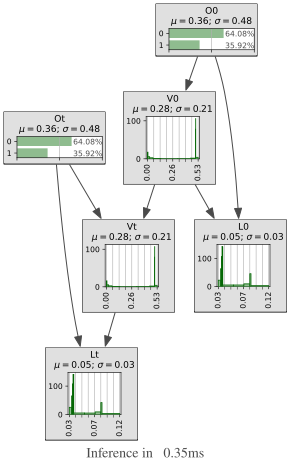

In [34]:

# DISCRETIZATION -- Compute binning once using one dataset (e.g., test_01)
discretizer=skbn.BNDiscretizer(defaultDiscretizationMethod='quantile')

# Set the same binning for all datasets
discretizer.setDiscretizationParameters('L0', 'quantile')
discretizer.setDiscretizationParameters('Lt', 'quantile')
discretizer.setDiscretizationParameters('V0', 'quantile')
discretizer.setDiscretizationParameters('Vt', 'quantile')
# discretizer.setDiscretizationParameters('L0', 'quantile', 3)
# discretizer.setDiscretizationParameters('Lt', 'quantile', 3)
# discretizer.setDiscretizationParameters('V0', 'expert', [0, 0.088, 0.499, 0.509])
# discretizer.setDiscretizationParameters('Vt', 'expert', [0, 0.088, 0.499, 0.509])

# Learn parameters for each dataset
bns = []
cms = []
for i, D in enumerate(datasets):
    discretized_D = discretizer.discretizedBN(D)  # Apply the same discretization
    auditDict=discretizer.audit(D)
    
    discretized_D.addArc("O0", "L0")
    discretized_D.addArc("O0", "V0")
    discretized_D.addArc("V0", "L0")
    discretized_D.addArc("Ot", "Vt")
    discretized_D.addArc("Ot", "Lt")
    discretized_D.addArc("Vt", "Lt")
    discretized_D.addArc("V0", "Vt")

    learner = pyAgrum.BNLearner(D, discretized_D)
    learner.useSmoothingPrior()
    bn = learner.learnParameters(discretized_D)
    bns.append(bn)
    print(f"BN p-obs{pobs[i]} learned.")
    gnb.showInference(bn, size=10)
    
    cm = pyc.CausalModel(bn)
    cms.append(cm)
    
    dirname = f"{OUTDIR}/CIE_battery_{pobs[i]}"
    pyAgrum.saveBN(bn, f"{dirname}/CIE_{pobs[i]}.bifxml")
    
    with open(f"{dirname}/AUDITs.pkl", "wb") as f:
        pickle.dump(auditDict, f)
